# BC wind: ERA5 via Open-Meteo
**ERA5 reanalysis (Copernicus/ECMWF), which assimilates satellite observations.**
Run in the environment installed from `requirements.txt`. No API key is needed.
[Archive documentation](https://open-meteo.com/en/docs/historical-weather-api) | [API limits](https://open-meteo.com/en/pricing).
ERA5 has 0.25-degree resolution; a 0.5-degree grid is sufficient for the game's regional wind field.
Open-Meteo currently lists ERA5 gusts as unavailable: request them, preserve nulls, and never substitute another model or invent gusts.

## 1. Config and BC grid

Grid: 569 points; 4416 hours per point.


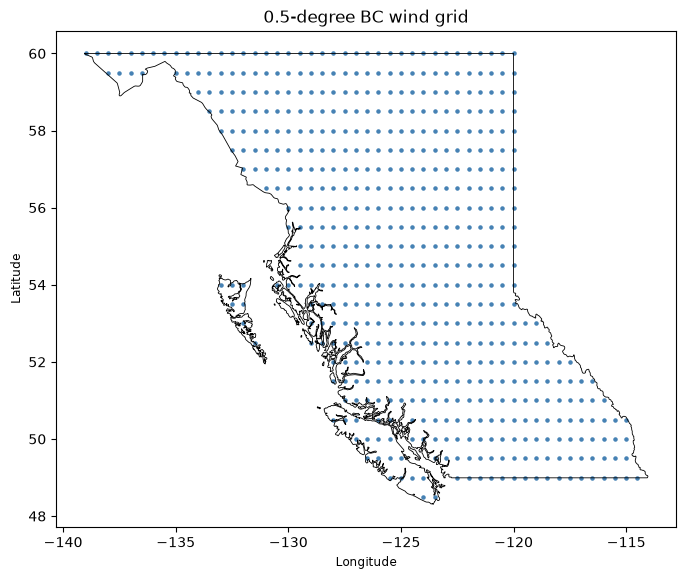

In [1]:
from pathlib import Path
import sys
import json
import hashlib
import time as clock
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import requests
from IPython.display import display

folder = Path.cwd().resolve()
REPO_ROOT = next((p for p in (folder, *folder.parents)
                  if (p / "CLAUDE.md").is_file()), None)
if REPO_ROOT is None:
    raise RuntimeError("Launch from the repository root or data folder.")
sys.path.insert(0, str(REPO_ROOT / "notebooks"))
from bc_geo import BC_BBOX, load_bc_boundary
from datetime import date
YEAR = 2023
START = date(YEAR, 5, 1)
END = date(YEAR, 10, 31)

GRID_STEP = 0.5
BATCH_SIZE = 10
MODEL = "era5"
API_URL = "https://archive-api.open-meteo.com/v1/archive"
VARIABLES = ["wind_speed_10m", "wind_direction_10m", "wind_gusts_10m"]
CACHE_DIR = REPO_ROOT / "data" / "raw" / "cache" / "wind"
OUTPUT_DIR = REPO_ROOT / "data" / "processed"
CACHE_DIR.mkdir(parents=True, exist_ok=True)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
SESSION = requests.Session()
EXPECTED_TIMES = pd.date_range(pd.Timestamp(START, tz="UTC"),
                               pd.Timestamp(END, tz="UTC") + pd.Timedelta(hours=23), freq="h")

bc = load_bc_boundary()
west, south, east, north = map(float, BC_BBOX.split(","))
# Anchor at half-degree multiples; avoid floating-point drift.
lons = np.arange(np.ceil(west / GRID_STEP), np.floor(east / GRID_STEP) + 1) * GRID_STEP
lats = np.arange(np.ceil(south / GRID_STEP), np.floor(north / GRID_STEP) + 1) * GRID_STEP
lon_mesh, lat_mesh = np.meshgrid(lons, lats)
candidates = gpd.GeoDataFrame({"lat": lat_mesh.ravel(), "lon": lon_mesh.ravel()},
    geometry=gpd.points_from_xy(lon_mesh.ravel(), lat_mesh.ravel()), crs="EPSG:4326")
grid = gpd.sjoin(candidates, bc, how="inner", predicate="within").drop(columns="index_right")
grid = grid.sort_values(["lat", "lon"]).reset_index(drop=True)
if grid.empty:
    raise RuntimeError("No grid points inside BC.")
print(f"Grid: {len(grid)} points; {len(EXPECTED_TIMES)} hours per point.")
ax = bc.boundary.plot(figsize=(8, 8), color="black", linewidth=0.6)
grid.plot(ax=ax, markersize=5, color="steelblue")
ax.set(title="0.5-degree BC wind grid", xlabel="Longitude", ylabel="Latitude")
plt.show()

## 2. Download and cache batches
Select `models=era5` explicitly, use UTC and km/h, and select the nearest model cell without elevation downscaling.
Long ranges and multiple locations count as multiple API calls; batching reduces HTTP overhead, not quota cost.
The free tier currently limits usage to 600/minute, 5,000/hour, and 10,000/day.
The estimate uses [Open-Meteo's published weighting formula](https://openmeteo.substack.com/p/weather-data-for-multiple-locations): locations x days/14 x variables/10, with at least one call per location and retry headroom.
It does not account for other usage on your IP. A 429 stops the run if bounded retries fail; rerun later to reuse caches.

In [2]:
def batch_params(batch):
    return {
        "latitude": ",".join(batch.lat.map(lambda x: f"{x:.4f}")),
        "longitude": ",".join(batch.lon.map(lambda x: f"{x:.4f}")),
        "start_date": START.isoformat(), "end_date": END.isoformat(),
        "hourly": ",".join(VARIABLES), "models": MODEL,
        "timezone": "GMT", "wind_speed_unit": "kmh",
        "cell_selection": "nearest", "elevation": "nan",
    }


def batch_to_table(payload, batch):
    locations = payload if isinstance(payload, list) else [payload]
    if len(locations) != len(batch):
        raise ValueError("API response location count differs from the requested batch.")
    frames = []
    for location, point in zip(locations, batch.itertuples(index=False)):
        if location.get("error"):
            raise ValueError(f"Open-Meteo: {location.get('reason', 'unknown error')}")
        if location.get("utc_offset_seconds") != 0:
            raise ValueError("API response is not UTC.")
        hourly = location.get("hourly", {})
        units = location.get("hourly_units", {})
        times = pd.DatetimeIndex(pd.to_datetime(hourly.get("time", []), utc=True))
        if not times.equals(EXPECTED_TIMES):
            raise ValueError("Missing, duplicate, or unexpected hourly timestamps.")
        data = {"time": times, "lat": point.lat, "lon": point.lon}
        # Store requested grid coordinates; API coordinates are snapped model-cell centers.
        for variable, column, unit in [
            ("wind_speed_10m", "speed_kmh", "km/h"),
            ("wind_direction_10m", "direction_deg", "°"),
            ("wind_gusts_10m", "gusts_kmh", "km/h"),
        ]:
            values = hourly.get(variable)
            if values is None and variable == "wind_gusts_10m":
                values = [None] * len(times)
            if not isinstance(values, list) or len(values) != len(times):
                raise ValueError(f"Missing or invalid {variable} array.")
            if units.get(variable) != unit and any(v is not None for v in values):
                raise ValueError(f"Unexpected units for {variable}: {units.get(variable)}")
            data[column] = pd.to_numeric(pd.Series(values), errors="raise").to_numpy(dtype=float)
        frame = pd.DataFrame(data)
        if frame[["speed_kmh", "direction_deg"]].isna().any().any():
            raise ValueError("ERA5 speed/direction data are missing; inspect the response.")
        if not np.isfinite(frame[["speed_kmh", "direction_deg"]].to_numpy()).all():
            raise ValueError("Non-finite wind values.")
        if (frame.speed_kmh < 0).any() or not frame.direction_deg.between(0, 360).all():
            raise ValueError("Wind values outside physical ranges.")
        gusts = frame.gusts_kmh.dropna()
        if (gusts < 0).any() or not np.isfinite(gusts).all():
            raise ValueError("Invalid gust values.")
        frames.append(frame)
    return pd.concat(frames, ignore_index=True)


def request_batch(params, batch, attempts=5):
    for attempt in range(attempts):
        try:
            response = SESSION.get(API_URL, params=params, timeout=(15, 180))
        except requests.RequestException:
            reason = "Open-Meteo network request failed."
            status = None
        else:
            status = response.status_code
            reason = f"HTTP {status}: {response.text[:1000]}"
            if status == 200:
                try:
                    payload = response.json()
                    batch_to_table(payload, batch)  # Validate before caching.
                    return payload
                except (ValueError, TypeError, KeyError) as exc:
                    reason = f"Invalid Open-Meteo response: {exc}"
            if status is not None and 400 <= status < 500 and status != 429:
                raise RuntimeError(reason)
        print(reason)
        if attempt + 1 < attempts:
            delay = min(60, 5 * 2 ** attempt)
            if status == 429:
                # Honor a short Retry-After; don't automatically sleep for hours.
                try:
                    retry_after = float(response.headers.get("Retry-After", delay))
                except ValueError:
                    retry_after = delay
                if retry_after > 60:
                    raise RuntimeError("Rate limit reached. Rerun later; cached batches are retained.")
                delay = max(delay, retry_after)
            print(f"Retry in {delay:g}s")
            clock.sleep(delay)
    raise RuntimeError(reason)

batches = [grid.iloc[i:i + BATCH_SIZE] for i in range(0, len(grid), BATCH_SIZE)]
days = (END - START).days + 1
# Conservative estimate; Open-Meteo calculates fractional call weights.
calls_per_location = max(1, np.ceil(days / 14 * len(VARIABLES) / 10))
estimated_calls = int(len(grid) * calls_per_location)
print(f"{len(batches)} HTTP batches; estimated weighted calls: {estimated_calls:,} (before retries)")
if estimated_calls > 8000:
    raise RuntimeError("Estimated usage leaves insufficient daily quota headroom. Reduce the range/grid.")
# Keep each full-season batch below ~400 weighted calls/minute, leaving retry headroom.
pause_seconds = max(1, BATCH_SIZE * calls_per_location / 400 * 60)

batch_tables = []
for number, batch in enumerate(batches, start=1):
    params = batch_params(batch)
    identity = json.dumps({"endpoint": API_URL, "params": params}, sort_keys=True)
    digest = hashlib.sha256(identity.encode()).hexdigest()[:20]
    cache_path = CACHE_DIR / f"era5_{START}_{END}_{digest}.json"
    if cache_path.exists():
        try:
            payload = json.loads(cache_path.read_text(encoding="utf-8"))
            table = batch_to_table(payload, batch)
        except (ValueError, TypeError, KeyError) as exc:
            raise RuntimeError(f"Invalid cache {cache_path.name}; remove it and rerun: {exc}") from None
        origin = "cache"
    else:
        payload = request_batch(params, batch)
        table = batch_to_table(payload, batch)
        temp_path = cache_path.with_suffix(".tmp")
        temp_path.write_text(json.dumps(payload), encoding="utf-8")
        temp_path.replace(cache_path)
        origin = "download"
        clock.sleep(pause_seconds)
    batch_tables.append(table)
    print(f"Batch {number}/{len(batches)}: {len(batch)} points, {len(table):,} rows ({origin})")

57 HTTP batches; estimated weighted calls: 2,276 (before retries)


RuntimeError: HTTP 400: {"reason":"Parameter 'elevation' must have the same number of elements as coordinates","error":true}

## 3. Combine hourly wind

In [ ]:
wind = pd.concat(batch_tables, ignore_index=True).sort_values(["time", "lat", "lon"]).reset_index(drop=True)
if wind.duplicated(["time", "lat", "lon"]).any():
    raise ValueError("Duplicate time/grid-point records.")
if len(wind) != len(grid) * len(EXPECTED_TIMES):
    raise ValueError("Incomplete grid/time coverage.")
print(f"Combined {len(wind):,} hourly grid records.")
print("Missing values:")
display(wind.isna().sum())
if wind.gusts_kmh.isna().any():
    print("ERA5 gusts unavailable for some/all hours; nulls are preserved, not filled or model-switched.")
display(wind.head())

## 4. Sanity checks

In [ ]:
display(wind[["speed_kmh", "direction_deg", "gusts_kmh"]].describe())
fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(wind.speed_kmh, bins=60, color="steelblue")
ax.set(title="BC ERA5 hourly wind speed distribution", xlabel="10 m wind speed (km/h)", ylabel="Hourly grid records")
plt.show()

# Weather wind direction is where wind blows FROM.
# Fire spreads TOWARD (direction + 180) % 360. Getting this backwards means fires spread into the wind.
map_time = pd.Timestamp(f"{YEAR}-08-17 15:00", tz="America/Vancouver").tz_convert("UTC")
afternoon = wind[wind.time == map_time].copy()
# Geographic east/north components: 0 degrees FROM north => flow south.
toward = np.deg2rad((afternoon.direction_deg + 180) % 360)
u = afternoon.speed_kmh * np.sin(toward)
v = afternoon.speed_kmh * np.cos(toward)
fig, ax = plt.subplots(figsize=(10, 9))
bc.boundary.plot(ax=ax, color="black", linewidth=0.6)
# Display in lon/lat with longitude scaled by cos(latitude) for east/north bearings.
# Use a fixed aspect and the same reference latitude in the quiver x components.
reference_lat = grid.lat.mean()
ax.set_aspect(1 / np.cos(np.deg2rad(reference_lat)))
arrows = ax.quiver(afternoon.lon, afternoon.lat, u / np.cos(np.deg2rad(reference_lat)), v,
                  afternoon.speed_kmh, cmap="viridis", angles="xy", scale_units="xy", scale=100, width=0.0025)
fig.colorbar(arrows, ax=ax, label="Wind speed (km/h)", shrink=0.7)
ax.set(title="ERA5 wind flow toward: August 17, 15:00 Vancouver time", xlabel="Longitude", ylabel="Latitude")
plt.show()

# Nearest requested grid point to Kelowna, using projected distances (metres).
kelowna = gpd.GeoSeries(gpd.points_from_xy([-119.496], [49.888]), crs="EPSG:4326").to_crs("EPSG:3005").iloc[0]
distances = grid.to_crs("EPSG:3005").distance(kelowna)
nearest = grid.loc[distances.idxmin()]
series = wind[(wind.lat == nearest.lat) & (wind.lon == nearest.lon)].sort_values("time")
print(f"Kelowna reference point: {nearest.lat}, {nearest.lon}; {distances.min()/1000:.1f} km from city.")
fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(series.time, series.speed_kmh, label="Speed", linewidth=0.7)
if series.gusts_kmh.notna().any():
    ax.plot(series.time, series.gusts_kmh, label="Gusts", linewidth=0.6, alpha=0.7)
ax.set(title="ERA5 wind near Kelowna", xlabel="Time (UTC)", ylabel="10 m wind (km/h)")
ax.legend()
fig.autofmt_xdate()
plt.show()

## 5. Save Parquet

In [ ]:
output_path = OUTPUT_DIR / f"wind_bc_{YEAR}.parquet"
wind.attrs.update({
    "source": "ERA5 reanalysis (Copernicus/ECMWF), which assimilates satellite observations",
    "provider": "Open-Meteo", "model": MODEL, "grid_step_degrees": GRID_STEP,
    "coordinates": "Requested BC grid points; API model cells may be snapped",
    "direction": "Meteorological FROM bearing, degrees clockwise from north",
    "gusts": "Unavailable ERA5 gusts remain null",
})
wind.to_parquet(output_path, engine="pyarrow", index=False, compression="snappy")
print(f"Saved {len(wind):,} rows to {output_path.relative_to(REPO_ROOT)}")